Generate data with outliers

In [1]:
import numpy as np

np.random.seed(42)

X_inliers = 0.3 * np.random.randn(100, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.r_[X_inliers, X_outliers]

n_outliers = len(X_outliers)
ground_truth = np.ones(len(X), dtype=int)
ground_truth[-n_outliers:] = -1

In [3]:
import pandas as pd
pd.DataFrame(X)

,0,1
0,2.149014,1.958521
1,2.194307,2.456909
2,1.929754,1.929759
3,2.473764,2.230230
4,1.859158,2.162768
...,...,...
215,-2.983516,0.177946
216,2.159948,-2.273432
217,0.983124,-3.317220
218,-3.586546,0.250837


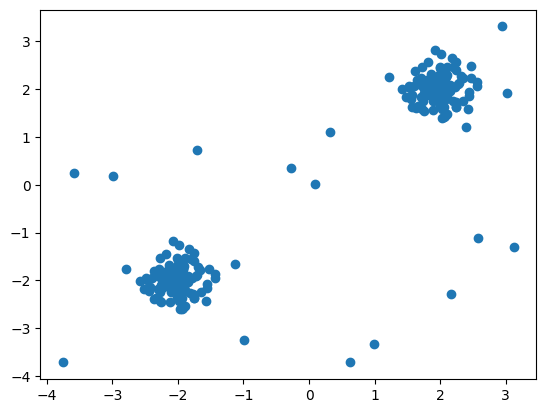

In [7]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])

In [8]:
from sklearn.neighbors import LocalOutlierFactor

clf = LocalOutlierFactor(
  n_neighbors=20, contamination=0.1
)

X_pred = clf.fit_predict(X)

In [11]:
X_pred

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,
       -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [9]:
n_errors = (X_pred != ground_truth).sum()
X_scores = clf.negative_outlier_factor_

In [13]:
import numpy as np

outliers_indices = np.where(X_pred == -1)
outliers_indices

(array([ 37,  89, 137, 156, 189, 200, 202, 204, 205, 206, 208, 209, 210,
        211, 212, 213, 214, 215, 216, 217, 218, 219], dtype=int64),)

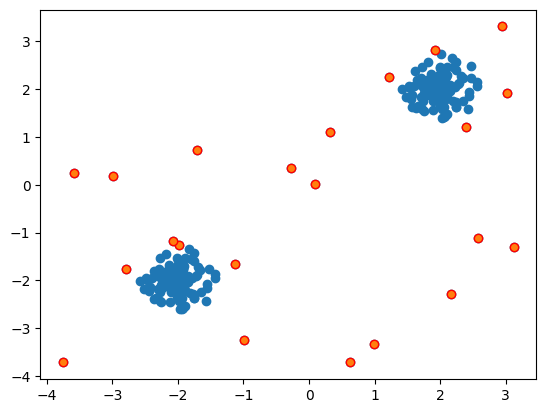

In [22]:
plt.scatter(X[:, 0], X[:, 1])
plt.scatter(X[outliers_indices, 0], X[outliers_indices, 1], edgecolors = "r")